#  UA Spend Exploration & CAC by Channel

First pass: what are we spending, where, and what's the blended and
marginal  cost per install by channel?

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)

## Load data

In [4]:
campaigns = pd.read_csv('ua_campaigns.csv')
spend = pd.read_csv('ua_spend.csv', parse_dates=['spend_date'])
players = pd.read_csv('players.csv', parse_dates=['install_date'])

print(spend.shape, players.shape)
spend.head()

(900, 6) (26245, 6)


,spend_id,campaign_id,channel,spend_date,daily_spend_usd,installs
0,1,1,paid_social,2026-01-01,46.0,46
1,2,2,paid_social,2026-01-01,47.0,47
2,3,3,paid_social,2026-01-01,47.0,47
3,4,4,paid_search,2026-01-01,49.3,17
4,5,5,paid_search,2026-01-01,49.3,17


## Total spend and installs by channel

In [5]:
by_channel = spend.groupby('channel').agg(
    total_spend=('daily_spend_usd', 'sum'),
    total_installs=('installs', 'sum'),
)
by_channel['blended_cac'] = by_channel['total_spend'] / by_channel['total_installs']
by_channel = by_channel.sort_values('total_spend', ascending=False)
by_channel.round(2)

,total_spend,total_installs,blended_cac
channel,,,
paid_social,19627.29,12742,1.54
paid_search,15579.51,4932,3.16
cross_promo,976.95,2171,0.45
organic,0.00,6400,0.00


`paid_social` is both the biggest spend line AND has the lowest blended
CAC. On a CPI-only dashboard, this channel looks like the obvious one to
keep scaling. Let's check whether that CAC has been stable.

## CPI trend over time, by channel

Blended (all-time average) CAC can hide a channel's cost trending up as
spend scales — a very common UA pattern as cheap inventory gets used up.

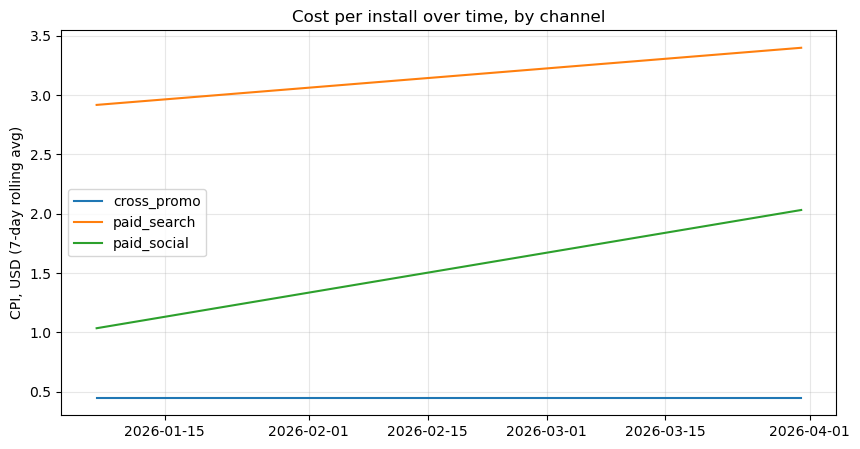

In [7]:
spend['cpi'] = spend['daily_spend_usd'] / spend['installs'].replace(0, np.nan)
daily_cpi = spend.groupby(['spend_date', 'channel'])['cpi'].mean().reset_index()

fig, ax = plt.subplots()
for channel, grp in daily_cpi.groupby('channel'):
    if channel == 'organic':
        continue
    ax.plot(grp['spend_date'], grp['cpi'].rolling(7).mean(), label=channel)
ax.set_ylabel('CPI, USD (7-day rolling avg)')
ax.set_title('Cost per install over time, by channel')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## First-30-days vs last-30-days CPI, by channel

In [8]:
spend_sorted = spend.sort_values('spend_date')
first_30 = spend_sorted[spend_sorted['spend_date'] < spend_sorted['spend_date'].min() + pd.Timedelta(days=30)]
last_30 = spend_sorted[spend_sorted['spend_date'] >= spend_sorted['spend_date'].max() - pd.Timedelta(days=30)]

def cac(df):
    g = df.groupby('channel').agg(spend=('daily_spend_usd', 'sum'), installs=('installs', 'sum'))
    return (g['spend'] / g['installs']).round(3)

cpi_shift = pd.DataFrame({
    'cac_first_30d': cac(first_30),
    'cac_last_30d': cac(last_30),
})
cpi_shift['pct_change'] = (cpi_shift['cac_last_30d'] / cpi_shift['cac_first_30d'] - 1) * 100
cpi_shift.round(3)

,cac_first_30d,cac_last_30d,pct_change
channel,,,
cross_promo,0.450,0.450,0.000
organic,0.000,0.000,NaN
paid_search,2.984,3.333,11.696
paid_social,1.174,1.888,60.818


## Finding: paid_social's real (marginal) cost is much higher than its blended average

`paid_social`'s cost per install has climbed significantly from the first
30 days of the window to the most recent 30 — the blended CAC in the
summary table above is being pulled down by cheap early spend that no
longer reflects what a new install actually costs today. Any decision to
scale this channel further should use the **recent** CAC, not the
all-time blended number.

`paid_search` and `cross_promo`, by contrast, show a stable cost curve —
their blended CAC is a reasonable proxy for what another dollar buys
right now.

## Installs over time, by channel

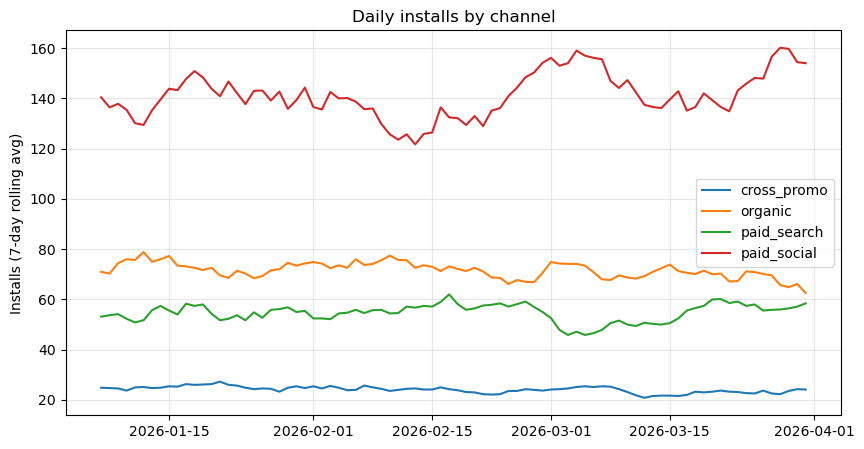

In [9]:
daily_installs = spend.groupby(['spend_date', 'channel'])['installs'].sum().reset_index()
fig, ax = plt.subplots()
for channel, grp in daily_installs.groupby('channel'):
    ax.plot(grp['spend_date'], grp['installs'].rolling(7).mean(), label=channel)
ax.set_ylabel('Installs (7-day rolling avg)')
ax.set_title('Daily installs by channel')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## LTV, ROAS & Payback Period by Channel

In [11]:
players = pd.read_csv('players.csv', parse_dates=['install_date'])
spend = pd.read_csv('ua_spend.csv', parse_dates=['spend_date'])
iap = pd.read_csv('iap_transactions.csv', parse_dates=['transaction_timestamp'])
ads = pd.read_csv('ad_revenue_events.csv', parse_dates=['event_timestamp'])

revenue = pd.concat([
    iap[['player_id', 'transaction_timestamp', 'usd_amount']]
        .rename(columns={'transaction_timestamp': 'event_ts', 'usd_amount': 'revenue'}),
    ads[['player_id', 'event_timestamp', 'revenue_usd']]
        .rename(columns={'event_timestamp': 'event_ts', 'revenue_usd': 'revenue'}),
])
print(f'{len(revenue):,} total revenue events (IAP + ads)')
revenue.head()

109,595 total revenue events (IAP + ads)


,player_id,event_ts,revenue
0,16,2026-01-03 15:00:00,0.99
1,35,2026-01-02 14:00:00,0.99
2,86,2026-01-04 10:00:00,0.99
3,92,2026-01-05 19:00:00,3.99
4,99,2026-01-02 20:00:00,9.99


## CAC by channel 

In [12]:
cac_by_channel = spend.groupby('channel').agg(
    total_spend=('daily_spend_usd', 'sum'),
    total_installs=('installs', 'sum'),
)
cac_by_channel['cac'] = cac_by_channel['total_spend'] / cac_by_channel['total_installs']
cac_by_channel[['cac']].round(3)

,cac
channel,
cross_promo,0.450
organic,0.000
paid_search,3.159
paid_social,1.540


## Build day-since-install revenue, joined to channel

In [13]:
r = revenue.merge(players[['player_id', 'channel', 'install_date']], on='player_id')
r['day'] = (r['event_ts'] - r['install_date']).dt.days
r = r[(r['day'] >= 0) & (r['day'] <= 90)]

installs_by_channel = players.groupby('channel')['player_id'].nunique()

## Cumulative LTV curve by channel

In [14]:
daily_rev = r.groupby(['channel', 'day'])['revenue'].sum().reset_index()
daily_rev['rev_per_install'] = daily_rev.apply(
    lambda row: row['revenue'] / installs_by_channel[row['channel']], axis=1
)
daily_rev = daily_rev.sort_values(['channel', 'day'])
daily_rev['cum_ltv'] = daily_rev.groupby('channel')['rev_per_install'].cumsum()
daily_rev.head()

,channel,day,revenue,rev_per_install,cum_ltv
0,cross_promo,0,85.2923,0.039287,0.039287
1,cross_promo,1,97.6631,0.044985,0.084272
2,cross_promo,2,64.9822,0.029932,0.114204
3,cross_promo,3,104.3732,0.048076,0.162280
4,cross_promo,4,47.4764,0.021868,0.184149


## LTV curves vs. CAC — the payback chart

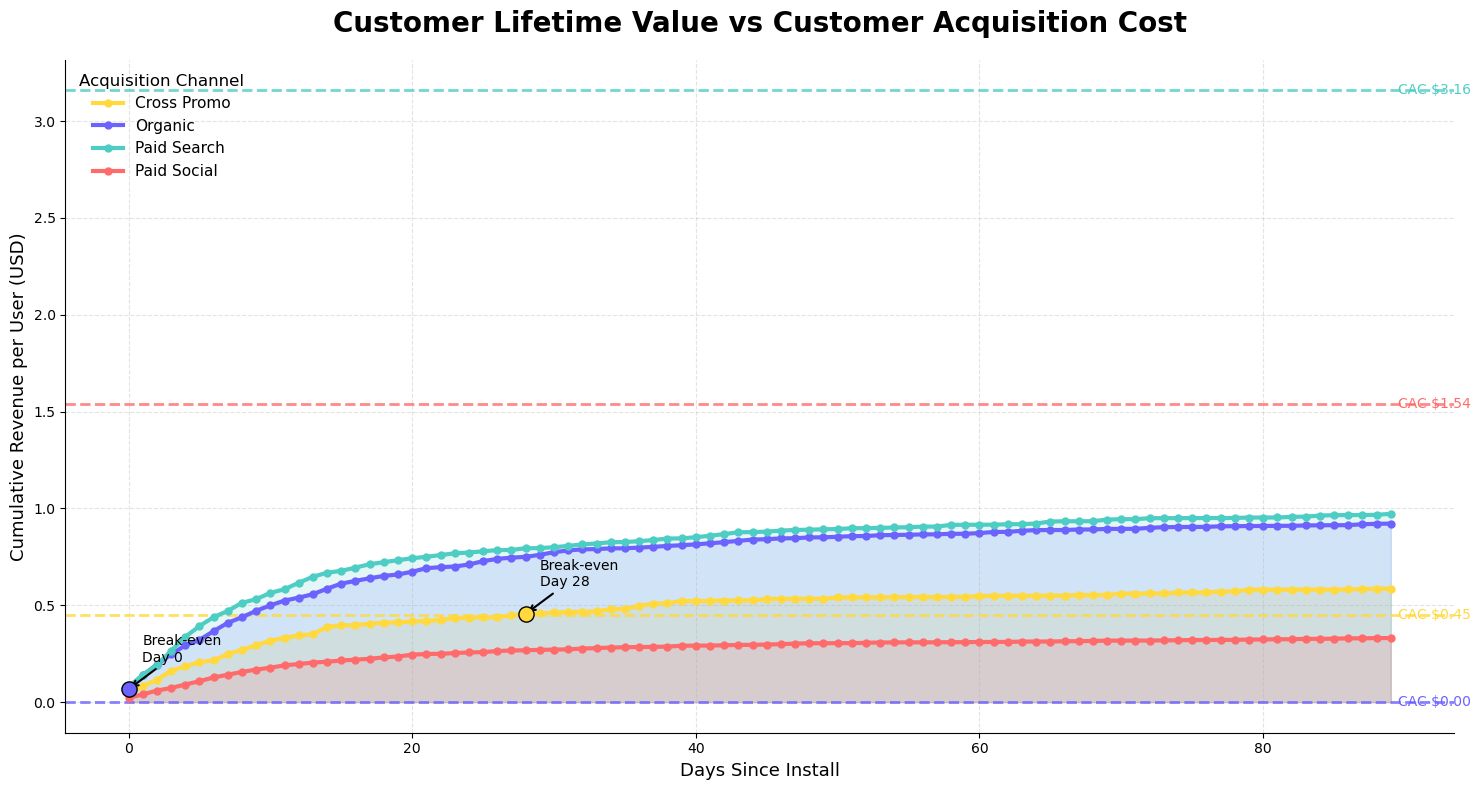

In [15]:
# Professional figure
fig, ax = plt.subplots(figsize=(15, 8))

colors = {
    "paid_social": "#FF6B6B",
    "paid_search": "#4ECDC4",
    "cross_promo": "#FFD93D",
    "organic": "#6C63FF"
}

for channel, grp in daily_rev.groupby("channel"):

    grp = grp.sort_values("day")

    # LTV Curve
    ax.plot(
        grp["day"],
        grp["cum_ltv"],
        linewidth=3,
        marker="o",
        markersize=5,
        label=f"{channel.replace('_',' ').title()}",
        color=colors[channel]
    )

    # Area
    ax.fill_between(
        grp["day"],
        grp["cum_ltv"],
        alpha=0.15,
        color=colors[channel]
    )

    # CAC Line
    cac = cac_by_channel.loc[channel, "cac"]

    ax.axhline(
        cac,
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        color=colors[channel]
    )

    # CAC Label
    ax.text(
        grp["day"].max() + 0.5,
        cac,
        f"CAC ${cac:.2f}",
        fontsize=10,
        color=colors[channel],
        va="center"
    )

    # Break-even point
    breakeven = grp[grp["cum_ltv"] >= cac]

    if not breakeven.empty:

        x = breakeven.iloc[0]["day"]
        y = breakeven.iloc[0]["cum_ltv"]

        ax.scatter(
            x,
            y,
            s=120,
            color=colors[channel],
            edgecolor="black",
            zorder=5
        )

        ax.annotate(
            f"Break-even\nDay {int(x)}",
            xy=(x, y),
            xytext=(10, 20),
            textcoords="offset points",
            fontsize=10,
            arrowprops=dict(
                arrowstyle="->",
                lw=1.5
            )
        )

# Titles
ax.set_title(
    "Customer Lifetime Value vs Customer Acquisition Cost",
    fontsize=20,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Days Since Install",
    fontsize=13
)

ax.set_ylabel(
    "Cumulative Revenue per User (USD)",
    fontsize=13
)

# Grid
ax.grid(
    linestyle="--",
    alpha=0.35
)

# Remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(
    title="Acquisition Channel",
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "ltv_vs_cac_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Payback period: first day cumulative LTV crosses CAC

In [16]:
def find_payback_day(channel):
    cac_val = cac_by_channel.loc[channel, 'cac']
    if cac_val == 0:
        return 0  # organic — no cost, "paid back" immediately
    grp = daily_rev[daily_rev['channel'] == channel].sort_values('day')
    crossed = grp[grp['cum_ltv'] >= cac_val]
    return int(crossed['day'].iloc[0]) if len(crossed) else None  # None = doesn't pay back in window

CHANNELS = list(cac_by_channel.index)

payback = pd.DataFrame({
    'channel': CHANNELS,
    'cac': cac_by_channel['cac'].values,
    'ltv_d90': [
        daily_rev[daily_rev['channel'] == c]['cum_ltv'].max()
        for c in CHANNELS
    ],
    'payback_day': [find_payback_day(c) for c in CHANNELS],
})
payback['roas_d90'] = (payback['ltv_d90'] / payback['cac'].replace(0, np.nan) * 100).round(1)
payback

,channel,cac,ltv_d90,payback_day,roas_d90
0,cross_promo,0.450000,0.586171,28.0,130.3
1,organic,0.000000,0.921802,0.0,NaN
2,paid_search,3.158863,0.972269,NaN,30.8
3,paid_social,1.540362,0.330815,NaN,21.5


## The finding: nobody pays back except cross_promo — and CPI ranked them backwards

| Channel | CAC | D90 LTV | Payback day | D90 ROAS |
|---|---|---|---|---|
| cross_promo | $0.45 | $0.59 | **Day 28** | **130.3%** |
| organic | $0.00 | $0.92 | Day 0 (free) | n/a |
| paid_search | $3.16 | $0.97 | Doesn't pay back in 90d | 30.8% |
| paid_social | $1.54 | $0.33 | Doesn't pay back in 90d | 21.5% |

- **`cross_promo`** is the only paid channel that actually pays back
  within the window — it crosses its own CAC by Day 28 and finishes at
  130% ROAS. It's also the *smallest* spend line in the portfolio.
- **`paid_search`** doesn't pay back within 90 days either, but its ROAS
  (30.8%) is meaningfully better than paid_social's (21.5%), and its LTV
  curve is still climbing steeply at Day 90 — worth a longer observation
  window before writing it off.
- **`paid_social`** has the lowest blended CAC of the three paid channels
  (see notebook 01) but the *worst* ROAS of all of them. Combined with
  notebook 01's finding that its marginal CAC is climbing, this channel
  is getting worse on both sides of the ledger while still absorbing the
  largest share of budget.

**CPI alone ranks these channels almost exactly backwards from what the
LTV data supports.**

## Budget reallocation recommendation (quantified)

Since `payback_day` is undefined (NaN) for two of the three paid
channels, we weight the reallocation by D90 ROAS instead — a metric that
works whether or not a channel has technically crossed breakeven yet.

Thought experiment: shift 30% of paid_social's spend into cross_promo and
paid_search, weighted by their relative ROAS.

In [17]:
paid_social_spend = cac_by_channel.loc['paid_social', 'total_spend']
shift_amount = paid_social_spend * 0.30

targets = ['cross_promo', 'paid_search']
roas_lookup = payback.set_index('channel')['roas_d90']
weight = {c: roas_lookup[c] for c in targets}
total_weight = sum(weight.values())
alloc = {c: shift_amount * (weight[c] / total_weight) for c in targets}

for c, amt in alloc.items():
    added_installs = amt / cac_by_channel.loc[c, 'cac']
    print(f'{c}: +${amt:,.0f} spend -> ~{added_installs:,.0f} additional installs '
          f'(CAC: ${cac_by_channel.loc[c, "cac"]:.2f}, D90 ROAS: {roas_lookup[c]:.1f}%)')

removed_installs = shift_amount / cac_by_channel.loc['paid_social', 'cac']
print(f'\npaid_social: -${shift_amount:,.0f} spend -> ~{removed_installs:,.0f} fewer '
      f'(D90 ROAS 21.5%) installs')

cross_promo: +$4,762 spend -> ~10,583 additional installs (CAC: $0.45, D90 ROAS: 130.3%)
paid_search: +$1,126 spend -> ~356 additional installs (CAC: $3.16, D90 ROAS: 30.8%)

paid_social: -$5,888 spend -> ~3,823 fewer (D90 ROAS 21.5%) installs


## Recommendation

**Cut paid_social spend by ~30% and reallocate to cross_promo and
paid_search, weighted toward cross_promo** — the only channel with
confirmed payback in the window and by far the best ROAS. This trades a
larger number of low-ROAS installs for a smaller number of installs with
a meaningfully better return, even before accounting for revenue that
will keep accruing past Day 90 for the paid_search cohort.

**Process recommendation:** track *marginal* CAC (recent-window, not
all-time blended — see notebook 01) and pair every CAC review with an
LTV/ROAS check. CPI alone rewarded scaling the worst-performing channel
here; cross_promo, the best performer, was also the most under-invested.